# K-mer MLP: Baseline, Regularization, and Hyperparameter Tuning

## Notebook goal
This notebook is organized around this week's focus: **regularization strategies and hyperparameter tuning** for a multi-label MLP on k-mer protein features.

### Design choice
To keep the notebook focused, the early sections only do the minimum setup needed to verify that the pipeline works:
- load processed k-mer features and GO labels
- define reusable datasets, models, and helper functions
- run a short baseline sanity check

The full threshold-based evaluation is deferred to the later tuning sections, where we compare settings systematically.

### Task summary
- **Input:** normalized 2-mer frequency vectors, dimension = 400
- **Output:** full GO label space, dimension = 31,454
- **Task type:** multi-label classification
- **This week's emphasis:** generalization, overfitting control, and parameter selection


## Step 0. Imports and Data Loading

### Why this step?
We begin by loading the processed k-mer features and GO labels that were already prepared in the preprocessing notebook.  
This avoids repeating sequence cleaning, k-mer extraction, feature scaling, and GO alignment.

### What we load
- `X_train.npy`, `X_val.npy`: standardized k-mer feature matrices
- `Y_train.npz`, `Y_val.npz`: sparse GO target matrices
- `meta.pkl`: metadata such as GO encoders and protein IDs

### Why this section is kept short
This notebook is not primarily about preprocessing.  
The goal here is simply to bring the prepared data into memory so that the tuning experiments can begin.


In [37]:
import os
import json
import copy
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score

In [2]:
DATA_DIR = "data_processed_kmer"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))

Y_train = load_npz(os.path.join(DATA_DIR, "Y_train.npz"))
Y_val   = load_npz(os.path.join(DATA_DIR, "Y_val.npz"))

with open(os.path.join(DATA_DIR, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("Y_train:", Y_train.shape, type(Y_train))
print("Y_val:  ", Y_val.shape, type(Y_val))

X_train: (112455, 400) float32
X_val:   (28114, 400) float32
Y_train: (112455, 31454) <class 'scipy.sparse._csr.csr_matrix'>
Y_val:   (28114, 31454) <class 'scipy.sparse._csr.csr_matrix'>


## Step 1. Define Shared Training Components

### Why this step?
All later experiments should reuse the same core pipeline.  
So instead of rewriting code for every tuning run, we define the reusable building blocks once:
- dataset class
- model class
- loss setup
- training loop
- validation loop
- threshold sweep
- helper functions for experiment configuration

### Why this matters
This structure keeps the notebook clean and makes it easier to compare:
- learning rates
- dropout levels
- weight decay values
- final model settings

### Important note
These definitions are shared by both the short baseline sanity check and the later regularization/tuning experiments.


In [3]:
class ProteinKmerDataset(Dataset):
    def __init__(self, X, Y_sparse):
        self.X = X.astype(np.float32)
        self.Y = Y_sparse.tocsr()
        self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        start = self.Y.indptr[idx]
        end = self.Y.indptr[idx + 1]
        pos_idx = self.Y.indices[start:end]

        y = torch.zeros(self.n_labels, dtype=torch.float32)
        y[pos_idx] = 1.0
        return x, y

In [4]:
train_dataset = ProteinKmerDataset(X_train, Y_train)
val_dataset   = ProteinKmerDataset(X_val, Y_val)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))

Train samples: 112455
Val samples:   28114


In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

print("Device:", device)
print("Input dim:", input_dim)
print("Output dim:", output_dim)

Device: cpu
Input dim: 400
Output dim: 31454


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [7]:
label_counts = np.asarray(Y_train.sum(axis=0)).ravel().astype(np.float32)
n_train = Y_train.shape[0]

# Compute positive class weights for each GO term.
# Add epsilon to avoid division by zero, then clip extreme values for stability.
pos_weight = (n_train - label_counts) / (label_counts + 1e-6)
pos_weight = np.clip(pos_weight, 1.0, 100.0)

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("label count min/max:", label_counts.min(), label_counts.max())
print("pos_weight min/max:", pos_weight.min(), pos_weight.max())

label count min/max: 0.0 73516.0
pos_weight min/max: 1.0 100.0


In [8]:
def build_dataloaders(train_dataset, val_dataset, batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader


def build_model(config, input_dim, output_dim, device):
    return MLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    ).to(device)


def build_optimizer(model, config):
    return optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    return all_probs, all_targets

In [10]:
def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro)
        })

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])
    return records, best_micro_row, best_macro_row


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device,
                              num_epochs=10, patience=3, save_path=None):
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss


def run_experiment(config, train_dataset, val_dataset, input_dim, output_dim, criterion, device,
                   run_threshold_sweep=True):
    train_loader, val_loader = build_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=config["batch_size"]
    )

    model = build_model(config, input_dim, output_dim, device)
    optimizer = build_optimizer(model, config)
    save_path = f"{config['save_prefix']}.pt"

    model, train_losses, val_losses, best_val_loss = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=config["num_epochs"],
        patience=config["patience"],
        save_path=save_path
    )

    result = {
        "config": config.copy(),
        "model": model,
        "model_path": save_path,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

    if run_threshold_sweep:
        val_probs, val_targets = get_predictions(model, val_loader, device)
        records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs)
        result["threshold_records"] = records
        result["best_micro_row"] = best_micro_row
        result["best_macro_row"] = best_macro_row

    return result

In [11]:
np.random.seed(42)

small_train_size = len(train_dataset) // 10
small_val_size = len(val_dataset) // 10

small_train_idx = np.random.choice(len(train_dataset), size=small_train_size, replace=False)
small_val_idx = np.random.choice(len(val_dataset), size=small_val_size, replace=False)

In [12]:
print(small_train_size)

11245


In [13]:
from torch.utils.data import Subset

train_dataset_small = Subset(train_dataset, small_train_idx)
val_dataset_small = Subset(val_dataset, small_val_idx)

## Step 2. Quick Baseline Sanity Check

### Why this step?
Before running full tuning experiments, we perform a short baseline run to verify that:
- the model trains without numerical issues
- validation loss stays finite
- checkpointing and dataloaders behave correctly

### Why we keep it short
This section is **not** the main focus of the notebook.  
It only serves as a sanity check, so we use a small number of epochs.

### Important note
We intentionally do **not** run threshold-based F1 evaluation here.  
Threshold selection is more meaningful in the later tuning and regularization sections, where settings are compared systematically.


In [14]:
BASELINE_CONFIG = {
    "hidden1": 512,
    "hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 5,
    "patience": 2,
    "save_prefix": "baseline_sanity_check"
}

baseline_result = run_experiment(
    config=BASELINE_CONFIG,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    output_dim=output_dim,
    criterion=criterion,
    device=device,
    run_threshold_sweep=True
)

print("Baseline best val loss:", baseline_result["best_val_loss"])

Epoch 01/5 | train_loss=0.131821 | val_loss=0.116899
Epoch 02/5 | train_loss=0.116948 | val_loss=0.114065
Epoch 03/5 | train_loss=0.114035 | val_loss=0.112398
Epoch 04/5 | train_loss=0.112389 | val_loss=0.110983
Epoch 05/5 | train_loss=0.111104 | val_loss=0.110793
Baseline best val loss: 0.11079309205101295


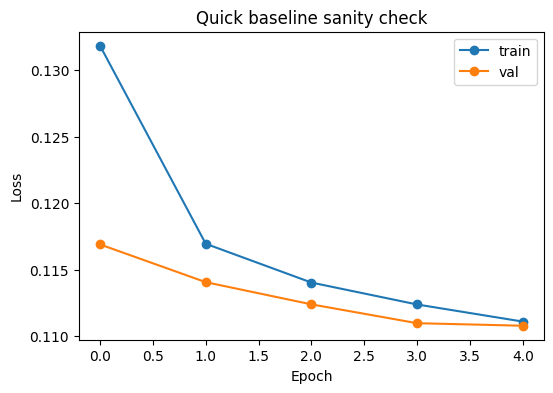

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(baseline_result["train_losses"], marker="o", label="train")
plt.plot(baseline_result["val_losses"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Quick baseline sanity check")
plt.legend()
plt.show()

In [16]:
summary = {
    "learning_rate": 1e-3,
    "dropout": 0.3,
    "weight_decay": 1e-5,
    "baseline_best_val_loss": float(baseline_result["best_val_loss"]),
    "baseline_best_micro": baseline_result["best_micro_row"],
    "baseline_best_macro": baseline_result["best_macro_row"],
    "baseline_model_path": baseline_result["model_path"],
}

with open("kmer_baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved tuning summary to kmer_baseline_summary.json")
print(summary)

Saved tuning summary to kmer_baseline_summary.json
{'learning_rate': 0.001, 'dropout': 0.3, 'weight_decay': 1e-05, 'baseline_best_val_loss': 0.11079309205101295, 'baseline_best_micro': {'threshold': 0.6500000000000001, 'micro_f1': 0.11965274088724821, 'macro_f1': 0.011004302698240912}, 'baseline_best_macro': {'threshold': 0.5500000000000002, 'micro_f1': 0.11479506077741274, 'macro_f1': 0.011135965008006805}, 'baseline_model_path': 'baseline_sanity_check.pt'}


## Step 3. Hyperparameter Tuning: Learning Rate

### Why this step?
We tune the learning rate first because it strongly affects optimization stability and convergence speed.

### What is fixed in this section?
We keep the architecture and regularization settings fixed, and only vary:
- `learning_rate`

### Selection rule
For each run, we perform threshold sweeping on the validation set and select the best learning rate using **best micro-F1**.


In [18]:
TUNING_BASE_CONFIG = {
    "hidden1": 512,
    "hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 3,
    "patience": 3,
    "save_prefix": "tuning_run"
}


In [17]:
learning_rates = [1e-2, 1e-3, 1e-4]
lr_results = []

for lr in learning_rates:
    print("=" * 80)
    print(f"Learning rate tuning: lr = {lr}")
    print("=" * 80)

    config = TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = lr
    config["save_prefix"] = f"kmer_lr_{lr}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    lr_results.append({
        "learning_rate": lr,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_macro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "best_threshold_macro": result["best_macro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_lr = pd.DataFrame(lr_results).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_lr)

Learning rate tuning: lr = 0.01
Epoch 01/3 | train_loss=0.167909 | val_loss=0.149168
Epoch 02/3 | train_loss=0.149745 | val_loss=0.146881
Epoch 03/3 | train_loss=0.143525 | val_loss=0.143856
Learning rate tuning: lr = 0.001
Epoch 01/3 | train_loss=0.191767 | val_loss=0.147525
Epoch 02/3 | train_loss=0.131763 | val_loss=0.130779
Epoch 03/3 | train_loss=0.120444 | val_loss=0.128468
Learning rate tuning: lr = 0.0001
Epoch 01/3 | train_loss=0.494228 | val_loss=0.365530
Epoch 02/3 | train_loss=0.252919 | val_loss=0.241398
Epoch 03/3 | train_loss=0.185322 | val_loss=0.196691


,learning_rate,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,best_threshold_macro,model_path
0,0.0010,0.128468,0.120304,0.004833,0.65,0.55,kmer_lr_0.001.pt
1,0.0001,0.196691,0.096637,0.002197,0.55,0.15,kmer_lr_0.0001.pt
2,0.0100,0.143856,0.075639,0.003817,0.55,0.45,kmer_lr_0.01.pt


In [18]:
best_lr_row = df_lr.iloc[0]
best_learning_rate = float(best_lr_row["learning_rate"])

print("Best learning rate:", best_learning_rate)
print("Best LR row:")
display(best_lr_row.to_frame())

Best learning rate: 0.001
Best LR row:


,0
learning_rate,0.001
best_val_loss,0.128468
best_micro_f1,0.120304
best_macro_f1,0.004833
best_threshold_micro,0.65
best_threshold_macro,0.55
model_path,kmer_lr_0.001.pt


## Step 4. Regularization Strategy 1: Dropout

### Why this step?
Dropout is a standard regularization technique that reduces overfitting by randomly masking hidden units during training.

### What is fixed in this section?
We fix the best learning rate from the previous step and vary:
- `dropout`

### Why this is a regularization experiment
Unlike learning rate, dropout does not primarily control optimization speed.  
Instead, it controls model complexity and encourages better generalization.


In [19]:
dropout_values = [0.0, 0.3, 0.5]
dropout_results = []

for dp in dropout_values:
    print("=" * 80)
    print(f"Dropout tuning: dropout = {dp}")
    print("=" * 80)

    config = TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate
    config["dropout"] = dp
    config["save_prefix"] = f"kmer_dropout_{dp}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    dropout_results.append({
        "dropout": dp,
        "learning_rate": best_learning_rate,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_macro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_dropout = pd.DataFrame(dropout_results).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_dropout)

Dropout tuning: dropout = 0.0
Epoch 01/3 | train_loss=0.187249 | val_loss=0.138472
Epoch 02/3 | train_loss=0.122765 | val_loss=0.128738
Epoch 03/3 | train_loss=0.108448 | val_loss=0.123687
Dropout tuning: dropout = 0.3
Epoch 01/3 | train_loss=0.192109 | val_loss=0.144682
Epoch 02/3 | train_loss=0.131652 | val_loss=0.135308
Epoch 03/3 | train_loss=0.120453 | val_loss=0.128778
Dropout tuning: dropout = 0.5
Epoch 01/3 | train_loss=0.198240 | val_loss=0.163706
Epoch 02/3 | train_loss=0.139146 | val_loss=0.141415
Epoch 03/3 | train_loss=0.130260 | val_loss=0.133398


,dropout,learning_rate,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,0.3,0.001,0.128778,0.118925,0.004672,0.65,kmer_dropout_0.3.pt
1,0.0,0.001,0.123687,0.117371,0.005665,0.65,kmer_dropout_0.0.pt
2,0.5,0.001,0.133398,0.104496,0.004046,0.55,kmer_dropout_0.5.pt


In [20]:
best_dropout_row = df_dropout.iloc[0]
best_dropout = float(best_dropout_row["dropout"])

print("Best dropout:", best_dropout)
print("Best dropout row:")
display(best_dropout_row.to_frame())

Best dropout: 0.3
Best dropout row:


,0
dropout,0.3
learning_rate,0.001
best_val_loss,0.128778
best_micro_f1,0.118925
best_macro_f1,0.004672
best_threshold_micro,0.65
model_path,kmer_dropout_0.3.pt


## Step 5. Regularization Strategy 2: Weight Decay

### Why this step?
Weight decay implements L2 regularization, which discourages overly large weights and can improve generalization.

### What is fixed in this section?
We fix:
- the best learning rate
- the best dropout setting

We then vary:
- `weight_decay`

### Why this section matters
This allows us to test whether explicit L2 regularization improves validation performance beyond dropout alone.


In [21]:
weight_decay_values = [0.0, 1e-5, 1e-4]
wd_results = []

for wd in weight_decay_values:
    print("=" * 80)
    print(f"Weight decay tuning: wd = {wd}")
    print("=" * 80)

    config = TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate
    config["dropout"] = best_dropout
    config["weight_decay"] = wd
    config["save_prefix"] = f"kmer_wd_{wd}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    wd_results.append({
        "weight_decay": wd,
        "learning_rate": best_learning_rate,
        "dropout": best_dropout,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_macro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_wd = pd.DataFrame(wd_results).sort_values("best_micro_f1", ascending=False).reset_index(drop=True)
display(df_wd)

Weight decay tuning: wd = 0.0
Epoch 01/3 | train_loss=0.188489 | val_loss=0.133086
Epoch 02/3 | train_loss=0.123393 | val_loss=0.126246
Epoch 03/3 | train_loss=0.111045 | val_loss=0.122710
Weight decay tuning: wd = 1e-05
Epoch 01/3 | train_loss=0.192248 | val_loss=0.141415
Epoch 02/3 | train_loss=0.131987 | val_loss=0.134198
Epoch 03/3 | train_loss=0.120237 | val_loss=0.128815
Weight decay tuning: wd = 0.0001
Epoch 01/3 | train_loss=0.269438 | val_loss=0.211412
Epoch 02/3 | train_loss=0.187120 | val_loss=0.187435
Epoch 03/3 | train_loss=0.169588 | val_loss=0.166680


,weight_decay,learning_rate,dropout,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,0.00000,0.001,0.3,0.122710,0.124372,0.004561,0.65,kmer_wd_0.0.pt
1,0.00001,0.001,0.3,0.128815,0.111210,0.004829,0.55,kmer_wd_1e-05.pt
2,0.00010,0.001,0.3,0.166680,0.109039,0.002977,0.55,kmer_wd_0.0001.pt


In [22]:
best_wd_row = df_wd.iloc[0]
best_weight_decay = float(best_wd_row["weight_decay"])

print("Best weight decay:", best_weight_decay)
print("Best weight decay row:")
display(best_wd_row.to_frame())

Best weight decay: 0.0
Best weight decay row:


,0
weight_decay,0.0
learning_rate,0.001
dropout,0.3
best_val_loss,0.12271
best_micro_f1,0.124372
best_macro_f1,0.004561
best_threshold_micro,0.65
model_path,kmer_wd_0.0.pt


## Step 6. Hidden Layer Size Tuning

### Why this step?
Hidden layer size controls model capacity.  
A model that is too small may underfit, while a model that is too large may overfit.

### What we test
We compare several hidden-layer configurations while keeping the previously selected learning rate, dropout, and weight decay fixed.

In [23]:
hidden_configs = [
    (256, 128),
    (512, 256),
    (1024, 512)
]

hidden_results = []

for h1, h2 in hidden_configs:
    print("=" * 80)
    print(f"Hidden layer tuning: hidden1 = {h1}, hidden2 = {h2}")
    print("=" * 80)

    config = TUNING_BASE_CONFIG.copy()
    config["learning_rate"] = best_learning_rate
    config["dropout"] = best_dropout
    config["weight_decay"] = best_weight_decay

    config["hidden1"] = h1
    config["hidden2"] = h2

    config["save_prefix"] = f"kmer_hidden_{h1}_{h2}"

    result = run_experiment(
        config=config,
        train_dataset=train_dataset_small,
        val_dataset=val_dataset_small,
        input_dim=input_dim,
        output_dim=output_dim,
        criterion=criterion,
        device=device,
        run_threshold_sweep=True
    )

    hidden_results.append({
        "hidden1": h1,
        "hidden2": h2,
        "learning_rate": best_learning_rate,
        "dropout": best_dropout,
        "weight_decay": best_weight_decay,
        "best_val_loss": result["best_val_loss"],
        "best_micro_f1": result["best_micro_row"]["micro_f1"],
        "best_macro_f1": result["best_macro_row"]["macro_f1"],
        "best_threshold_micro": result["best_micro_row"]["threshold"],
        "model_path": result["model_path"]
    })

df_hidden = pd.DataFrame(hidden_results)\
    .sort_values("best_micro_f1", ascending=False)\
    .reset_index(drop=True)

display(df_hidden)

Hidden layer tuning: hidden1 = 256, hidden2 = 128
Epoch 01/3 | train_loss=0.233393 | val_loss=0.142216
Epoch 02/3 | train_loss=0.130835 | val_loss=0.129332
Epoch 03/3 | train_loss=0.120152 | val_loss=0.125514
Hidden layer tuning: hidden1 = 512, hidden2 = 256
Epoch 01/3 | train_loss=0.187814 | val_loss=0.134163
Epoch 02/3 | train_loss=0.123682 | val_loss=0.126424
Epoch 03/3 | train_loss=0.110980 | val_loss=0.122869
Hidden layer tuning: hidden1 = 1024, hidden2 = 512
Epoch 01/3 | train_loss=0.167297 | val_loss=0.129602
Epoch 02/3 | train_loss=0.117415 | val_loss=0.123721
Epoch 03/3 | train_loss=0.101200 | val_loss=0.122067


,hidden1,hidden2,learning_rate,dropout,weight_decay,best_val_loss,best_micro_f1,best_macro_f1,best_threshold_micro,model_path
0,1024,512,0.001,0.3,0.0,0.122067,0.125309,0.006195,0.65,kmer_hidden_1024_512.pt
1,256,128,0.001,0.3,0.0,0.125514,0.117692,0.003518,0.55,kmer_hidden_256_128.pt
2,512,256,0.001,0.3,0.0,0.122869,0.116566,0.004801,0.65,kmer_hidden_512_256.pt


In [24]:
best_hidden_row = df_hidden.iloc[0]

best_hidden1 = int(best_hidden_row["hidden1"])
best_hidden2 = int(best_hidden_row["hidden2"])

print("Best hidden layer:")
print(f"hidden1 = {best_hidden1}, hidden2 = {best_hidden2}")

print("Best hidden row:")
display(best_hidden_row.to_frame())

Best hidden layer:
hidden1 = 1024, hidden2 = 512
Best hidden row:


,0
hidden1,1024
hidden2,512
learning_rate,0.001
dropout,0.3
weight_decay,0.0
best_val_loss,0.122067
best_micro_f1,0.125309
best_macro_f1,0.006195
best_threshold_micro,0.65
model_path,kmer_hidden_1024_512.pt


## Step 7. Final Model with Best Hyperparameters

### Why this step?
After tuning optimization and regularization settings separately, we now combine the best choices into one final configuration.

### What is included in the final configuration?
- best learning rate
- best dropout
- best weight decay
- early stopping during training

### Why threshold sweep is used here
This is the stage where we want final threshold-based evaluation, so we now run full validation threshold sweeping and record the best micro-F1 and macro-F1.


In [25]:
FINAL_CONFIG = TUNING_BASE_CONFIG.copy()
FINAL_CONFIG["learning_rate"] = best_learning_rate
FINAL_CONFIG["dropout"] = best_dropout
FINAL_CONFIG["weight_decay"] = best_weight_decay
FINAL_CONFIG["save_prefix"] = "kmer_final_best_model"
FINAL_CONFIG["hidden1"] = best_hidden1
FINAL_CONFIG["hidden2"] = best_hidden2
FINAL_CONFIG["num_epochs"] = 5

print("Final config:")
print(FINAL_CONFIG)

Final config:
{'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'kmer_final_best_model'}


In [19]:
FINAL_CONFIG = TUNING_BASE_CONFIG.copy()
FINAL_CONFIG["learning_rate"] = 0.001
FINAL_CONFIG["dropout"] = 0.3
FINAL_CONFIG["weight_decay"] = 0.0
FINAL_CONFIG["save_prefix"] = "kmer_final_best_model"
FINAL_CONFIG["hidden1"] = 1024
FINAL_CONFIG["hidden2"] = 512
FINAL_CONFIG["num_epochs"] = 5

print("Final config:")
print(FINAL_CONFIG)

Final config:
{'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'kmer_final_best_model'}


In [20]:
final_result = run_experiment(
    config=FINAL_CONFIG,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    output_dim=output_dim,
    criterion=criterion,
    device=device,
    run_threshold_sweep=True
)

print("Final best val loss:", final_result["best_val_loss"])
print("Final best micro-F1:", final_result["best_micro_row"])
print("Final best macro-F1:", final_result["best_macro_row"])
print("Final model path:", final_result["model_path"])

Epoch 01/5 | train_loss=0.122307 | val_loss=0.107770
Epoch 02/5 | train_loss=0.102305 | val_loss=0.102425
Epoch 03/5 | train_loss=0.094040 | val_loss=0.099089
Epoch 04/5 | train_loss=0.087643 | val_loss=0.097275
Epoch 05/5 | train_loss=0.082268 | val_loss=0.096157
Final best val loss: 0.09615734141658652
Final best micro-F1: {'threshold': 0.7500000000000002, 'micro_f1': 0.15100675250213816, 'macro_f1': 0.043645012593634964}
Final best macro-F1: {'threshold': 0.6500000000000001, 'micro_f1': 0.14822306532506102, 'macro_f1': 0.04733017257481324}
Final model path: kmer_final_best_model.pt


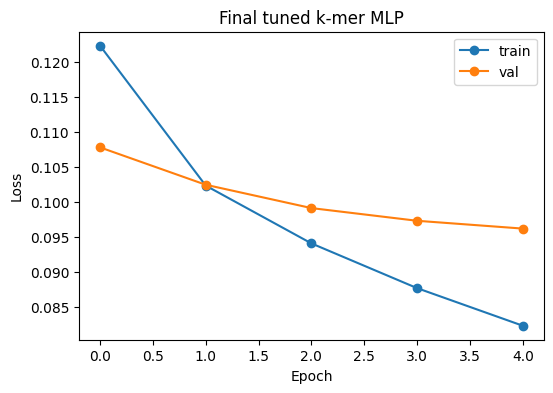

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(final_result["train_losses"], marker="o", label="train")
plt.plot(final_result["val_losses"], marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final tuned k-mer MLP")
plt.legend()
plt.show()

,threshold,micro_f1,macro_f1
0,0.05,0.021305,0.007374
1,0.15,0.039700,0.014324
2,0.25,0.058377,0.023285
3,0.35,0.079864,0.032660
4,0.45,0.104735,0.040573
5,0.55,0.130148,0.045857
6,0.65,0.148223,0.047330
7,0.75,0.151007,0.043645
8,0.85,0.125362,0.034464


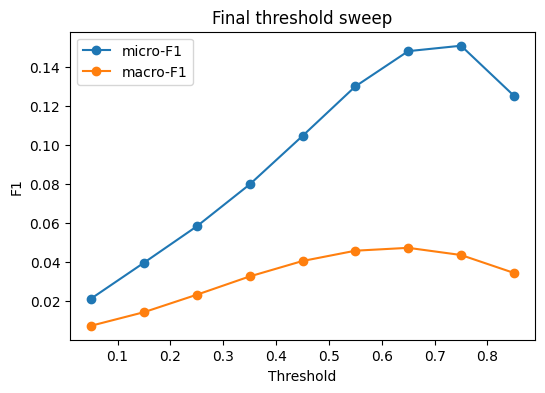

In [22]:
df_thresh = pd.DataFrame(final_result["threshold_records"])
display(df_thresh)

plt.figure(figsize=(6, 4))
plt.plot(df_thresh["threshold"], df_thresh["micro_f1"], marker="o", label="micro-F1")
plt.plot(df_thresh["threshold"], df_thresh["macro_f1"], marker="o", label="macro-F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Final threshold sweep")
plt.legend()
plt.show()

## Step 8. Save the Selected Hyperparameters and Final Results

### Why this step?
Saving the selected configuration makes the experiment reproducible and lets us reuse the tuned settings later, for example:
- as the final k-mer baseline
- as a starting point for future comparisons
- as a template for the ESM notebook

### What we save
We save:
- the best learning rate
- the best dropout value
- the best weight decay value
- the final validation metrics
- the best threshold information


In [29]:
summary = {
    "best_learning_rate": best_learning_rate,
    "best_dropout": best_dropout,
    "best_weight_decay": best_weight_decay,
    "final_best_val_loss": float(final_result["best_val_loss"]),
    "final_best_micro": final_result["best_micro_row"],
    "final_best_macro": final_result["best_macro_row"],
    "final_model_path": final_result["model_path"],
}

with open("kmer_tuning_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved tuning summary to kmer_tuning_summary.json")
print(summary)

Saved tuning summary to kmer_tuning_summary.json
{'best_learning_rate': 0.001, 'best_dropout': 0.3, 'best_weight_decay': 0.0, 'final_best_val_loss': 0.09626565076072108, 'final_best_micro': {'threshold': 0.7500000000000002, 'micro_f1': 0.15036308447686397, 'macro_f1': 0.042363616960929}, 'final_best_macro': {'threshold': 0.6500000000000001, 'micro_f1': 0.14809684198717687, 'macro_f1': 0.04641646766062745}, 'final_model_path': 'kmer_final_best_model.pt'}


## Step 9. IA-Weighted F1-max Evaluation

### Why this step?
In addition to micro-F1 and macro-F1, we also want a threshold-based metric that accounts for the informativeness of each GO term.

The provided `IA.txt` file contains information accretion (IA) weights for GO terms.  
These weights let us compute **weighted precision** and **weighted recall**, which can then be combined into an **IA-weighted F1** across thresholds.

### What we do
In this section, we:
- load `IA.txt`
- align IA weights to the same GO-term order used by the label matrix
- compute **F1-max**, defined here as the maximum IA-weighted F1 across thresholds

### Why this matters
Standard micro-F1 and macro-F1 treat labels differently but do not explicitly account for GO-term informativeness.  
The IA-weighted F1-max provides an ontology-aware complementary metric.

In [25]:
def load_ia_weights(path):
    ia_map = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            go_term, weight = line.split()
            ia_map[go_term] = float(weight)
    return ia_map


IA_PATH = ("../cafa-5-protein-function-prediction/IA.txt")

ia_map = load_ia_weights(IA_PATH)
go_terms = meta["go_terms"].tolist()
ia_weights = np.array([ia_map.get(go, 0.0) for go in go_terms], dtype=np.float32)

print("Number of GO terms:", len(go_terms))
print("Number of IA entries:", len(ia_map))
print("IA weights shape:", ia_weights.shape)
print("IA weight min/max:", ia_weights.min(), ia_weights.max())
print("Nonzero IA weights:", int((ia_weights > 0).sum()))
for i in range(5):
    print(go_terms[i], ia_weights[i])


Number of GO terms: 31454
Number of IA entries: 43248
IA weights shape: (31454,)
IA weight min/max: 0.0 15.492651
Nonzero IA weights: 23242
GO:0000001 0.0
GO:0000002 3.1038358
GO:0000003 3.439404
GO:0000006 4.409391
GO:0000007 5.409391


In [26]:
def weighted_fmax_from_probs(y_true, y_prob, ia_weights, thresholds=None):
    """
    Compute IA-weighted precision, recall, and F1 across thresholds,
    then return the full threshold records and the best row.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    eps = 1e-12
    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fn = ((y_true == 1) & (y_pred == 0)).sum(axis=0).astype(np.float64)

        weighted_tp = (tp * ia_weights).sum()
        weighted_fp = (fp * ia_weights).sum()
        weighted_fn = (fn * ia_weights).sum()

        weighted_precision = weighted_tp / (weighted_tp + weighted_fp + eps)
        weighted_recall = weighted_tp / (weighted_tp + weighted_fn + eps)
        weighted_f1 = 2 * weighted_precision * weighted_recall / (weighted_precision + weighted_recall + eps)

        records.append({
            "threshold": float(t),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
        })

    best_row = max(records, key=lambda x: x["weighted_f1"])
    return records, best_row

## Step 10. Evaluate Baseline and Tuned Models on the Same Validation Set

### Why this step?
To compare the baseline and tuned models fairly, we evaluate both saved checkpoints on the **same validation set**.

### What we compare
For each model, we compute:
- best **micro-F1**
- best **macro-F1**
- best **IA-weighted F1-max**

### Why this is useful
This lets us measure whether tuning improved not only ordinary multi-label classification performance but also ontology-aware weighted performance.

In [27]:
def evaluate_saved_model(config, model_path, train_dataset, val_dataset, input_dim, output_dim, device):
    """
    Load a saved checkpoint and return validation probabilities and targets.
    """
    _, val_loader = build_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=config["batch_size"]
    )

    model = build_model(config, input_dim, output_dim, device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    val_probs, val_targets = get_predictions(model, val_loader, device)
    return val_probs, val_targets

# Baseline checkpoint
baseline_model_path = baseline_result["model_path"]
baseline_config_eval = BASELINE_CONFIG.copy()

# Tuned checkpoint
tuned_model_path = final_result["model_path"]
tuned_config_eval = FINAL_CONFIG.copy()

# Get validation probabilities and targets from both models
baseline_probs, baseline_targets = evaluate_saved_model(
    config=baseline_config_eval,
    model_path=baseline_model_path,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    output_dim=output_dim,
    device=device
)

tuned_probs, tuned_targets = evaluate_saved_model(
    config=tuned_config_eval,
    model_path=tuned_model_path,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    output_dim=output_dim,
    device=device
)

print("baseline_probs:", baseline_probs.shape)
print("tuned_probs:", tuned_probs.shape)
print("baseline_targets:", baseline_targets.shape)
print("tuned_targets:", tuned_targets.shape)

baseline_probs: (28114, 31454)
tuned_probs: (28114, 31454)
baseline_targets: (28114, 31454)
tuned_targets: (28114, 31454)


In [28]:
thresholds = np.arange(0.05, 0.95, 0.1)

# Reuse existing standard threshold sweep results
baseline_records = baseline_result["threshold_records"]
baseline_best_micro = baseline_result["best_micro_row"]
baseline_best_macro = baseline_result["best_macro_row"]

tuned_records = final_result["threshold_records"]
tuned_best_micro = final_result["best_micro_row"]
tuned_best_macro = final_result["best_macro_row"]



# IA-weighted F1-max
baseline_fmax_records, baseline_best_fmax = weighted_fmax_from_probs(
    baseline_targets, baseline_probs, ia_weights, thresholds=thresholds
)
tuned_fmax_records, tuned_best_fmax = weighted_fmax_from_probs(
    tuned_targets, tuned_probs, ia_weights, thresholds=thresholds
)

print("Baseline best micro:", baseline_best_micro)
print("Baseline best macro:", baseline_best_macro)
print("Baseline best F1-max:", baseline_best_fmax)
print()
print("Tuned best micro:", tuned_best_micro)
print("Tuned best macro:", tuned_best_macro)
print("Tuned best F1-max:", tuned_best_fmax)

Baseline best micro: {'threshold': 0.6500000000000001, 'micro_f1': 0.11965274088724821, 'macro_f1': 0.011004302698240912}
Baseline best macro: {'threshold': 0.5500000000000002, 'micro_f1': 0.11479506077741274, 'macro_f1': 0.011135965008006805}
Baseline best F1-max: {'threshold': 0.7500000000000002, 'weighted_precision': 0.0761715978261248, 'weighted_recall': 0.14691639465150316, 'weighted_f1': 0.10032683877892377}

Tuned best micro: {'threshold': 0.7500000000000002, 'micro_f1': 0.15100675250213816, 'macro_f1': 0.043645012593634964}
Tuned best macro: {'threshold': 0.6500000000000001, 'micro_f1': 0.14822306532506102, 'macro_f1': 0.04733017257481324}
Tuned best F1-max: {'threshold': 0.7500000000000002, 'weighted_precision': 0.10092332040535999, 'weighted_recall': 0.22822795304916493, 'weighted_f1': 0.13995706344519207}


## Step 11. Baseline vs Tuned Comparison Table and Figure

### Why this step?
After computing all three metrics for both models, we summarize them in a compact comparison table and a bar chart.

### Metrics shown
- **micro-F1**: best threshold-based overall performance
- **macro-F1**: best threshold-based balanced performance across labels
- **F1-max**: best IA-weighted F1 across thresholds

### Interpretation goal
This final comparison shows whether hyperparameter tuning improved the model from both a standard multi-label perspective and an ontology-aware weighted perspective.

In [29]:
comparison_df = pd.DataFrame([
    {
        "model": "baseline",
        "micro_f1": baseline_best_micro["micro_f1"],
        "micro_threshold": baseline_best_micro["threshold"],
        "macro_f1": baseline_best_macro["macro_f1"],
        "macro_threshold": baseline_best_macro["threshold"],
        "f1_max": baseline_best_fmax["weighted_f1"],
        "f1_max_threshold": baseline_best_fmax["threshold"],
    },
    {
        "model": "tuned",
        "micro_f1": tuned_best_micro["micro_f1"],
        "micro_threshold": tuned_best_micro["threshold"],
        "macro_f1": tuned_best_macro["macro_f1"],
        "macro_threshold": tuned_best_macro["threshold"],
        "f1_max": tuned_best_fmax["weighted_f1"],
        "f1_max_threshold": tuned_best_fmax["threshold"],
    }
])

display(comparison_df)


,model,micro_f1,micro_threshold,macro_f1,macro_threshold,f1_max,f1_max_threshold
0,baseline,0.119653,0.65,0.011136,0.55,0.100327,0.75
1,tuned,0.151007,0.75,0.047330,0.65,0.139957,0.75


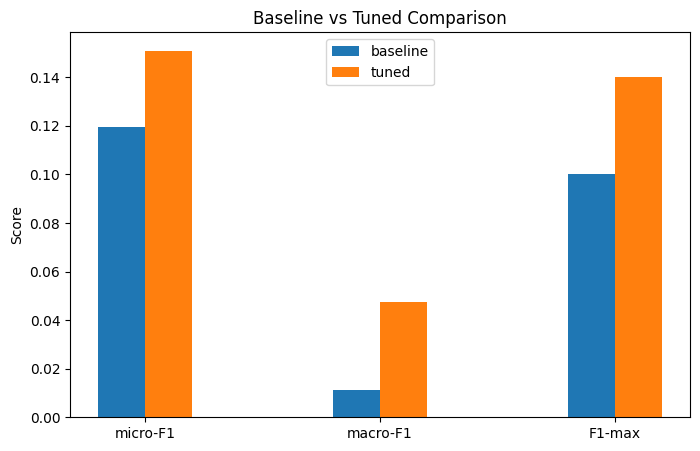

In [35]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["micro-F1", "macro-F1", "F1-max"]

baseline_scores = [
    comparison_df.loc[comparison_df["model"] == "baseline", "micro_f1"].values[0],
    comparison_df.loc[comparison_df["model"] == "baseline", "macro_f1"].values[0],
    comparison_df.loc[comparison_df["model"] == "baseline", "f1_max"].values[0],
]

tuned_scores = [
    comparison_df.loc[comparison_df["model"] == "tuned", "micro_f1"].values[0],
    comparison_df.loc[comparison_df["model"] == "tuned", "macro_f1"].values[0],
    comparison_df.loc[comparison_df["model"] == "tuned", "f1_max"].values[0],
]

x = np.arange(len(metrics))
width = 0.20

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_scores, width=width, label="baseline")
plt.bar(x + width/2, tuned_scores, width=width, label="tuned")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Tuned Comparison")
plt.legend()
plt.show()

## Step 12. Optional Threshold-Curve Comparison

### Why this step?
A single summary score is useful, but threshold curves reveal *how* performance changes across thresholds.

### What we visualize
We compare:
- baseline vs tuned **micro-F1** threshold curves
- baseline vs tuned **IA-weighted F1-max** curves

These plots help explain whether tuning improves performance broadly or only at a narrow threshold range.

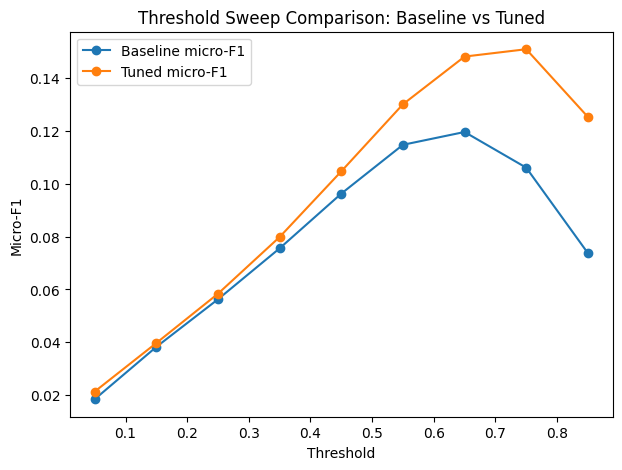

In [31]:
df_thresh_baseline = pd.DataFrame(baseline_records)
df_thresh_tuned = pd.DataFrame(tuned_records)

plt.figure(figsize=(7, 5))
plt.plot(df_thresh_baseline["threshold"], df_thresh_baseline["micro_f1"], marker="o", label="Baseline micro-F1")
plt.plot(df_thresh_tuned["threshold"], df_thresh_tuned["micro_f1"], marker="o", label="Tuned micro-F1")
plt.xlabel("Threshold")
plt.ylabel("Micro-F1")
plt.title("Threshold Sweep Comparison: Baseline vs Tuned")
plt.legend()
plt.show()

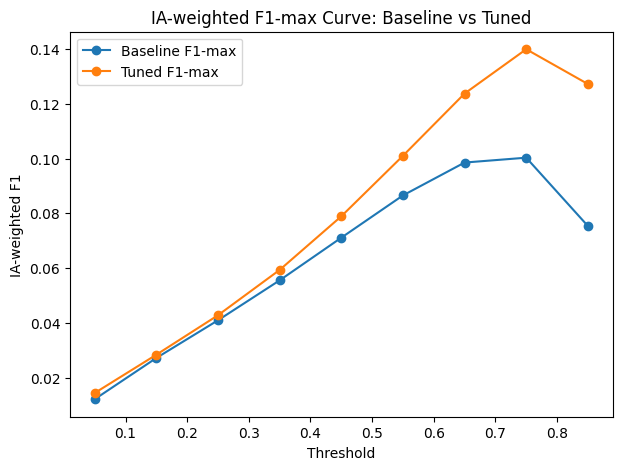

In [32]:
df_fmax_baseline = pd.DataFrame(baseline_fmax_records)
df_fmax_tuned = pd.DataFrame(tuned_fmax_records)

plt.figure(figsize=(7, 5))
plt.plot(df_fmax_baseline["threshold"], df_fmax_baseline["weighted_f1"], marker="o", label="Baseline F1-max")
plt.plot(df_fmax_tuned["threshold"], df_fmax_tuned["weighted_f1"], marker="o", label="Tuned F1-max")
plt.xlabel("Threshold")
plt.ylabel("IA-weighted F1")
plt.title("IA-weighted F1-max Curve: Baseline vs Tuned")
plt.legend()
plt.show()

## Summary and Interpretation

### What this notebook accomplished
This notebook reorganized the k-mer MLP workflow so that the early sections only perform a short baseline sanity check, while the main emphasis is placed on:
- hyperparameter tuning
- regularization strategies
- final threshold-based model selection

### Key methodological choices
- short baseline run without threshold sweeping
- learning rate tuned first as an optimization hyperparameter
- dropout and weight decay evaluated as regularization strategies
- early stopping used during all tuning runs
- final threshold sweep used only after selecting the best settings

### Why this structure is appropriate
This notebook reflects the intended focus of the week's assignment:
- identifying stable training settings
- reducing overfitting
- improving validation generalization
- documenting the selected final hyperparameters
